In [1]:

import os
import sys
import glob
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


project_root = os.path.abspath('../../')
if project_root not in sys.path:
    sys.path.append(project_root)

# Configuraciones
with open('../../configs/experiments/feat_task_k5_diag_pca90.yaml', 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_dir = os.path.join("../../outputs/processed/experiments/feature_hmm/task/", cfg['experiment']['name'])
features_dir = "../../data/interim/features/task/"

print("Cargando Caminos de Viterbi y Mega-Vectores Originales...")
viterbi_paths = np.load(os.path.join(exp_dir, 'viterbi_paths_k5.npy'))

# Cargar el Mega-Vector original
feature_files = sorted(glob.glob(os.path.join(features_dir, '*_features.npy')))
X_original = np.vstack([np.load(f) for f in feature_files])

print(f"Dimensiones de Viterbi: {viterbi_paths.shape}")
print(f"Dimensiones Originales: {X_original.shape}")

Cargando Caminos de Viterbi y Mega-Vectores Originales...
Dimensiones de Viterbi: (143899,)
Dimensiones Originales: (143899, 114)


In [2]:
scaler = StandardScaler()
X_zscored = scaler.fit_transform(X_original)

n_states = cfg['pipeline']['hmm']['k_states']
print(f"Detectados {n_states} estados desde la configuración...")

state_profiles = []

for s in range(n_states):
    # Aislar solo las ventanas donde el cerebro estaba en el estado 's'
    idx_state = (viterbi_paths == s)
    state_mean = np.mean(X_zscored[idx_state], axis=0)
    state_profiles.append(state_mean)

state_profiles = np.array(state_profiles) # Shape: (n_states, 114)
print(f"¡Perfiles calculados exitosamente para K={n_states}!")

Detectados 5 estados desde la configuración...
¡Perfiles calculados exitosamente para K=5!


C:\Users\pokem\AppData\Local\Temp\ipykernel_25164\1730450274.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, .9, 1])


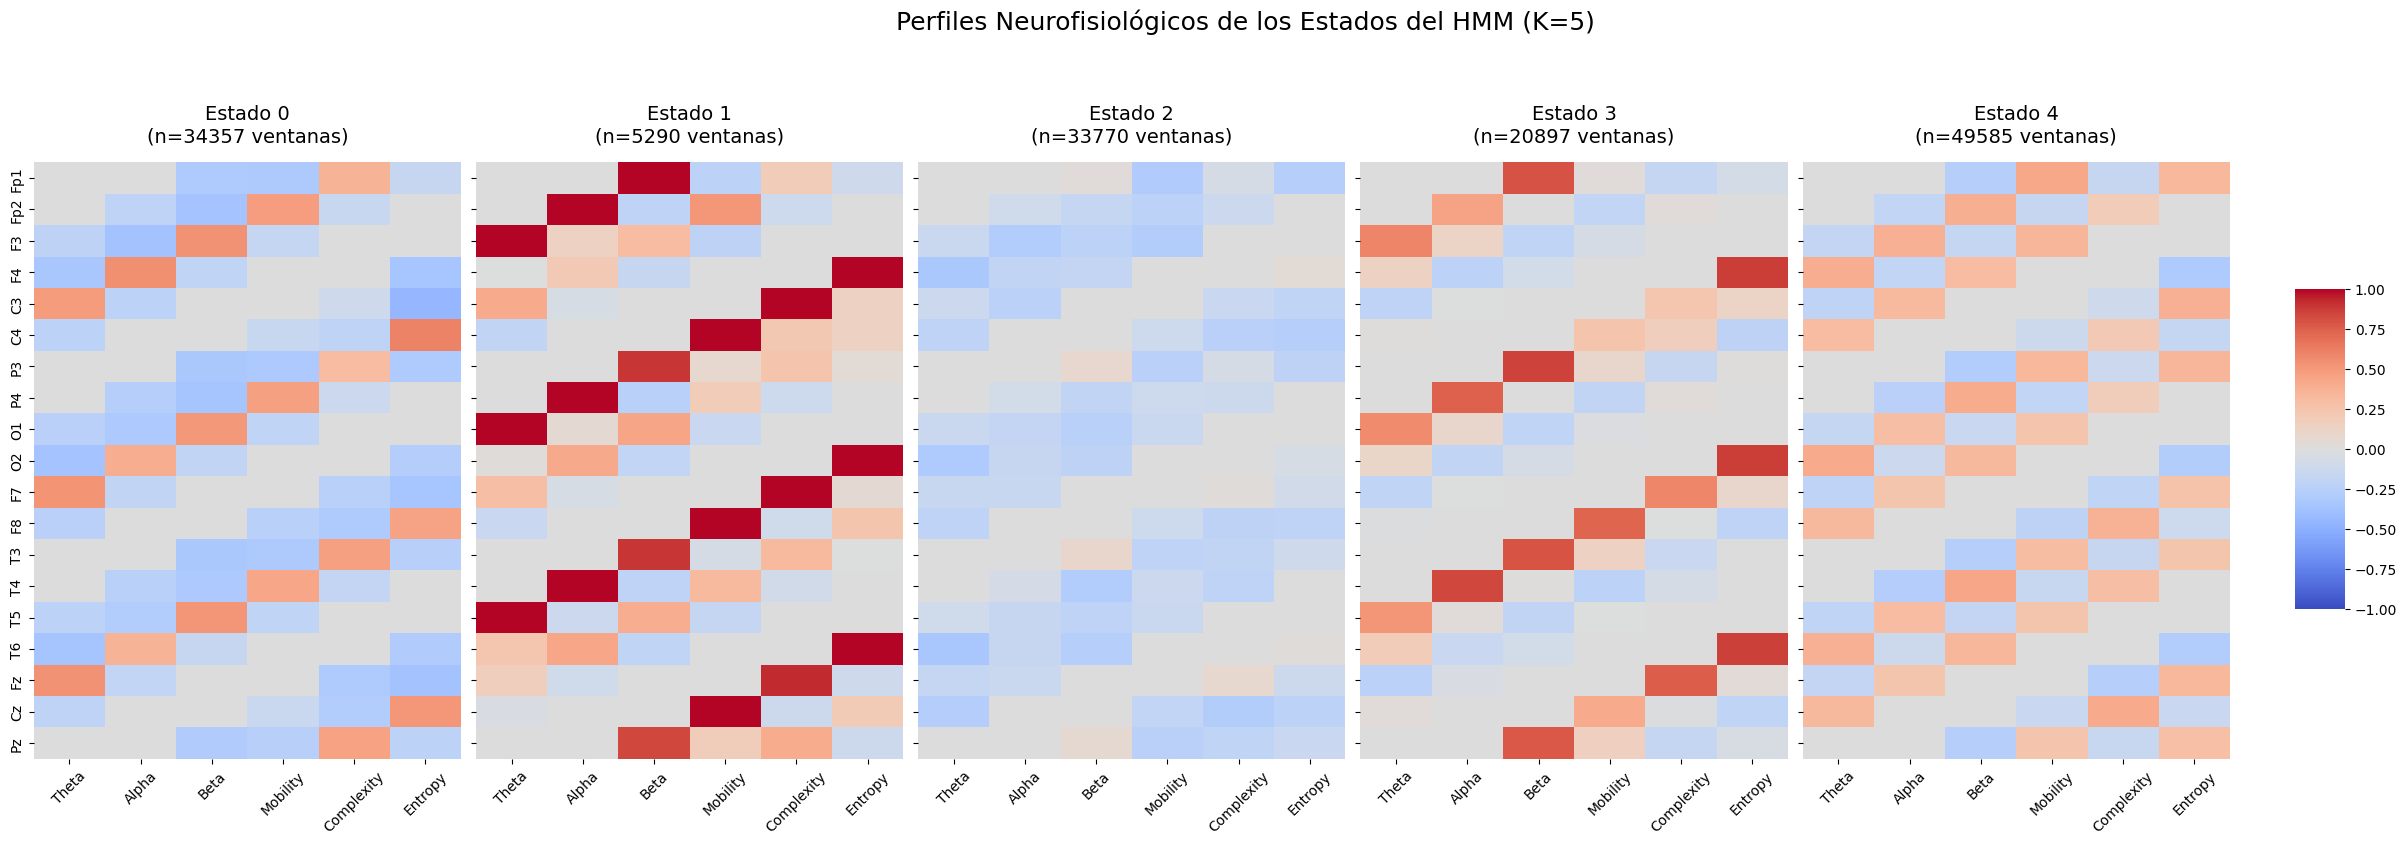

In [3]:
# 1. CONVERSIÓN A 3D (Dinámica según n_states)
ch_names = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']
metrics = ['Theta', 'Alpha', 'Beta', 'Mobility', 'Complexity', 'Entropy']

# Aquí está la clave: Creamos una nueva matriz vacía con el n_states actualizado (4)
state_profiles_3d = np.zeros((n_states, len(ch_names), len(metrics)))

for m_idx, metric in enumerate(metrics):
    start_col = m_idx * len(ch_names)
    end_col = (m_idx + 1) * len(ch_names)
    state_profiles_3d[:, :, m_idx] = state_profiles[:, start_col:end_col]

# 2. GRAFICACIÓN
fig, axes = plt.subplots(1, n_states, figsize=(5 * n_states, 8), sharey=True)
cbar_ax = fig.add_axes([.92, .3, .02, .4])

for s in range(n_states):
    ax = axes[s]
    sns.heatmap(
        state_profiles_3d[s], 
        cmap='coolwarm', 
        center=0, 
        annot=False, 
        xticklabels=metrics, 
        yticklabels=ch_names,
        ax=ax,
        cbar=s == 0,
        cbar_ax=None if s > 0 else cbar_ax,
        vmin=-1, vmax=1
    )
    ax.set_title(f"Estado {s}\n(n={np.sum(viterbi_paths == s)} ventanas)", fontsize=14, pad=15)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f"Perfiles Neurofisiológicos de los Estados del HMM (K={n_states})", fontsize=18, y=1.05)
plt.tight_layout(rect=[0, 0, .9, 1])
plt.show()

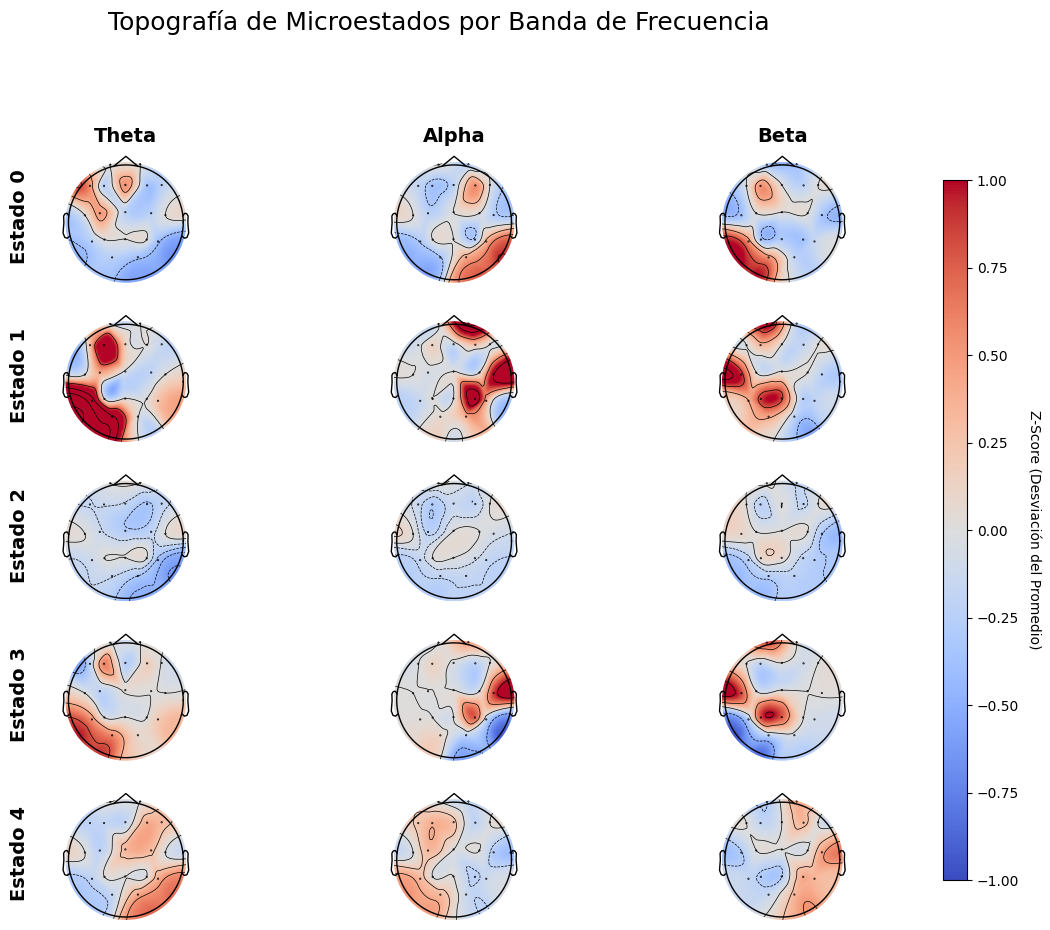

In [4]:
import mne
import matplotlib.pyplot as plt

# 1. Crear la "plantilla" de la cabeza (Montage)
# Usamos tus mismos 19 canales en el orden exacto de tu Mega-Vector
ch_names = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']

# Creamos un objeto Info de MNE y le asignamos el casco estándar 10-20
info = mne.create_info(ch_names=ch_names, sfreq=250., ch_types='eeg') # sfreq es irrelevante para el mapa espacial
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

# 2. Seleccionar qué métricas queremos ver en las cabezas
# Índices de tus métricas: 0=Theta, 1=Alpha, 2=Beta
metric_indices = {'Theta': 0, 'Alpha': 1, 'Beta': 2}
n_metrics = len(metric_indices)

# 3. Dibujar el Grid (3 Estados x 3 Bandas)
fig, axes = plt.subplots(n_states, n_metrics, figsize=(12, 10))

for s in range(n_states):
    for m_idx, (m_name, m_col) in enumerate(metric_indices.items()):
        ax = axes[s, m_idx]
        
        # Extraer los 19 valores (uno por canal) para este estado y esta métrica
        # state_profiles_3d viene de tu celda de visualización anterior!
        data_to_plot = state_profiles_3d[s, :, m_col] 
        
        # El motor de MNE que dibuja la cabecita
        im, _ = mne.viz.plot_topomap(
            data_to_plot, 
            pos=info, 
            axes=ax, 
            cmap='coolwarm', 
            vlim=(-1, 1),
            show=False,
            contours=4, # Agrega líneas topográficas como si fuera un mapa geográfico
            sphere=(0.0, 0.0, 0.0, 0.1) # Ajuste visual de la cabeza
        )
        
        # Títulos
        if s == 0:
            ax.set_title(f"{m_name}", fontsize=14, fontweight='bold')
        if m_idx == 0:
            ax.set_ylabel(f"Estado {s}", fontsize=14, fontweight='bold', labelpad=20)

# Barra de color compartida
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Z-Score (Desviación del Promedio)', rotation=270, labelpad=15)

plt.suptitle("Topografía de Microestados por Banda de Frecuencia", fontsize=18, y=1.02)
plt.show()